In [23]:
import xarray as xr
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.shapereader import natural_earth, Reader
import cartopy.io.shapereader as shpreader
import warnings
import os
warnings.filterwarnings('ignore')

## Extract data by countries

In [85]:
country_list = ['Senegal', 'Guinea', 'Côte d\'Ivoire', 'Ghana', 'Togo', 'Benin', 'Cameroon']

df = pd.read_csv('./data/disease/main/IHME-GBD_2021_DATA-a5c34232-1.csv')

df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,1,Number,1990,22234.055231,25657.098111,18961.516019
1,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,2,Percent,1990,0.000292,0.000340,0.000246
2,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,3,Rate,1990,182.274256,210.336280,155.446057
3,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,1,Number,1991,22712.828814,26270.097478,19400.280193
4,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,2,Percent,1991,0.000288,0.000335,0.000245


In [15]:
df['location_name'].unique()

array(["Côte d'Ivoire", 'Benin', 'Ghana', 'Nigeria', 'Cameroon',
       'Guinea-Bissau', 'Senegal', 'Togo', 'Gambia', 'Guinea'],
      dtype=object)

In [24]:
for country in df['location_name'].unique():
    print(country)
    df[df['metric_name'] == 'Number']
    df['location_name']==country

Côte d'Ivoire
Benin
Ghana
Nigeria
Cameroon
Guinea-Bissau
Senegal
Togo
Gambia
Guinea


In [10]:
df_men_number = df[df['metric_name'] == 'Number']

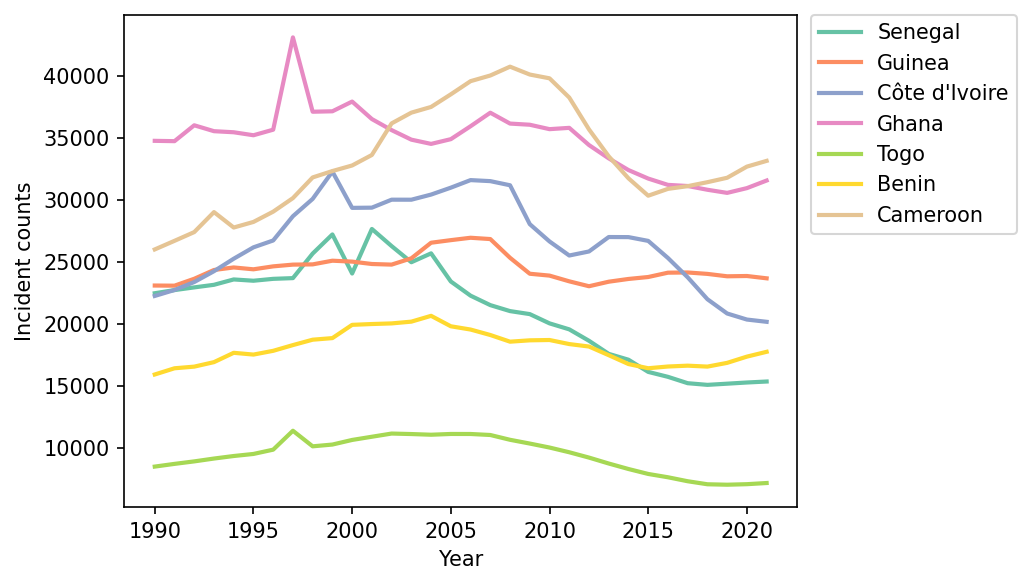

In [86]:
# First, the temperature plot
plt.figure(figsize=(7, 4), dpi=150)

cmap = plt.get_cmap('Set2')

for country_index, country in enumerate(country_list):
    #print(country_index)
    #print(country)
    # os.mkdir(f'./data/disease/by country/{country}')
    # df_men_number[df_men_number['location_name']== country].to_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    #meningitis_incident.set_index('year')
    plt.plot(meningitis_incident['year'], meningitis_incident['val'], label=f'{country}', color=cmap(country_index), linestyle='-', linewidth=2)
    
    #plt.fill_between(meningitis_incident['year'], meningitis_incident['lower'], meningitis_incident['upper'], color=cmap(country_index), linewidth=0, alpha=0.2)


# Add title and labels
plt.xlabel('Year')
plt.ylabel('Incident counts')

# Show legend
plt.legend(bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          borderaxespad=0.)

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()  

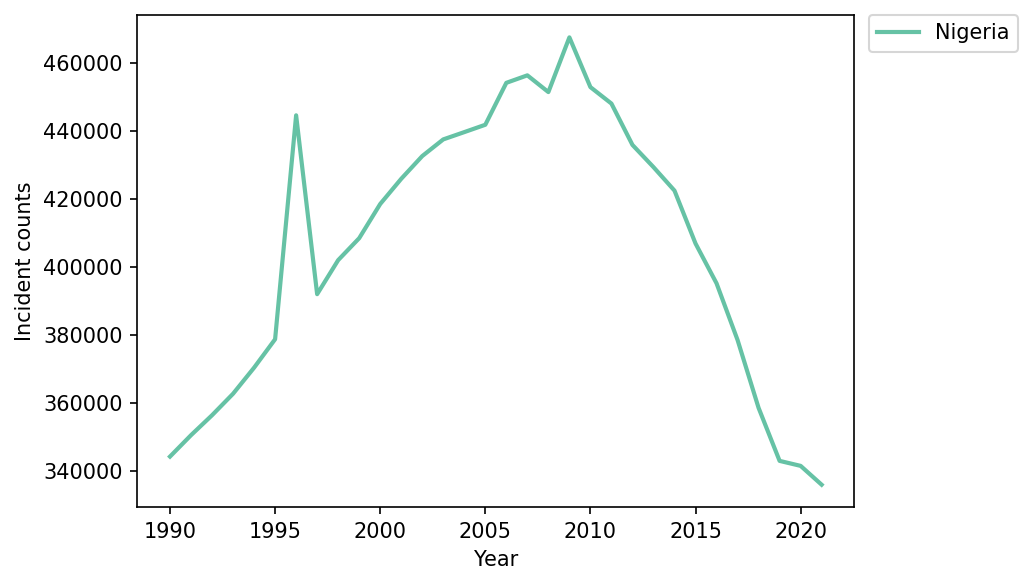

In [87]:
country_list =['Nigeria']

# First, the temperature plot
plt.figure(figsize=(7, 4), dpi=150)

cmap = plt.get_cmap('Set2')

for country_index, country in enumerate(country_list):
    #print(country_index)
    #print(country)
    # os.mkdir(f'./data/disease/by country/{country}')
    # df_men_number[df_men_number['location_name']== country].to_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    #meningitis_incident.set_index('year')
    plt.plot(meningitis_incident['year'], meningitis_incident['val'], label=f'{country}', color=cmap(country_index), linestyle='-', linewidth=2)
    
    #plt.fill_between(meningitis_incident['year'], meningitis_incident['lower'], meningitis_incident['upper'], color=cmap(country_index), linewidth=0, alpha=0.2)


# Add title and labels
plt.xlabel('Year')
plt.ylabel('Incident counts')

# Show legend
plt.legend(bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          borderaxespad=0.)

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()  

## Plotting

In [3]:
Benin_meningitis_incident = pd.read_csv('./data/disease/by country/Benin/Benin_meningitis_incident.csv')
Benin_meningitis_incident.set_index('year')
Benin_meningitis_incident.head()


,Unnamed: 0,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,96,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1990,15901.031310,18563.385113,13408.585090
1,99,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1991,16401.530009,19167.733685,13850.751812
2,102,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1992,16534.989651,19374.458008,13947.833773
3,105,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1993,16897.201663,19873.435804,14273.360617
4,108,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1994,17649.402513,20836.451699,14956.443165


<Axes: xlabel='year'>

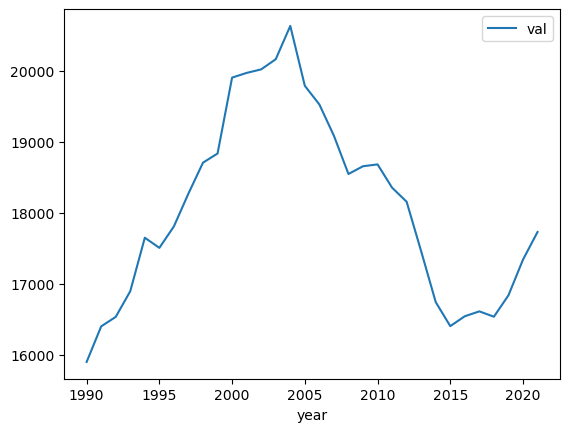

In [49]:
Benin_meningitis_incident.plot(x='year', y='val')

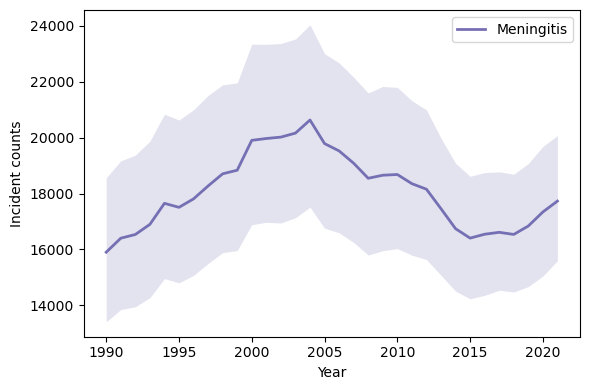

In [ ]:
## Plot monthly climatologies with shading showing min/max for each calendar month
########################################################################################

# First, the temperature plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Benin_meningitis_incident['year'], Benin_meningitis_incident['val'], label='Benin', color='#7570b3', linestyle='-', linewidth=2)
#ax.plot(Benin_meningitis_incident.index, Benin_meningitis_incident['Jaffna'], label='Jaffna', color=color_Jaffna, linestyle='-', linewidth=2)

ax.fill_between(Benin_meningitis_incident['year'], Benin_meningitis_incident['lower'], Benin_meningitis_incident['upper'], color='#7570b3', linewidth=0, alpha=0.2)
# ax.fill_between(Benin_meningitis_incident.index, Benin_meningitis_incident['lower'], Benin_meningitis_incident['upper'], color=Benin_meningitis_incident['val'], linewidth=0, alpha=0.2)

# Add title and labels
ax.set_xlabel('Year')
ax.set_ylabel('Incident counts')

# Show legend
ax.legend()

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()

# Next, the precipitation plot
#fig, ax = plt.subplots(figsize=(6, 4))

#ax.plot(prcp_monthlyClim.index, prcp_monthlyClim['Negombo'], label='Negombo', color=color_Negombo, linestyle='-', linewidth=2)
#ax.plot(prcp_monthlyClim.index, prcp_monthlyClim['Jaffna'], label='Jaffna', color=color_Jaffna, linestyle='-', linewidth=2)

#ax.fill_between(prcp_monthlyClim.index, prcp_monthlyMin['Negombo'], prcp_monthlyMax['Negombo'], color=color_Negombo, linewidth=0, alpha=0.2)
#ax.fill_between(prcp_monthlyClim.index, prcp_monthlyMin['Jaffna'], prcp_monthlyMax['Jaffna'], color=color_Jaffna, linewidth=0, alpha=0.2)

# Add title and labels
#ax.set_xlabel('Month')
#ax.set_ylabel('Precipitation (mm/month)')

# Show legend
#ax.legend()

# Adjust layout to avoid label cutoff
#plt.tight_layout()

#plt.show()

## Stats